# Ljungqvist & Sargent (2018), Chapter 9 --- Overlapping Generations

Companion notebook to `ls_solutions_ch09.pdf`. Chapter 9 has **13 end-of-chapter exercises**
(printed pp. 366--378). All are analytical, so every section here is a numerical sanity check of the
key analytical results, each confirmed by an independent route with an `assert`: saving functions by
numerical optimisation vs closed forms; forward recursions vs closed-form price paths; `brentq` roots
vs quadratic formulas; direct utility comparisons for the Pareto claims. Parameters are chosen here
(the book gives numbers only in 9.3(c)) and stated in each section.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq, minimize_scalar

plt.rcParams.update({"pdf.fonttype": 42, "font.size": 10})  # TrueType, never Type 3
FIG = "fig/"


def u(c, gam):
    '''CRRA period utility c^(1-gam)/(1-gam); log when gam == 1.'''
    return np.log(c) if gam == 1 else c ** (1 - gam) / (1 - gam)


def s_closed(R, w1, w2, gam):
    '''Saving function of Exercise 9.1(a): s(R) = (w1 - R^(-1/gam) w2) / (1 + R^(1-1/gam)).'''
    return (w1 - R ** (-1 / gam) * w2) / (1 + R ** (1 - 1 / gam))


def s_numeric(R, y1, y2, gam):
    '''Independent route: maximise u(y1 - s) + u(y2 + R s) over s numerically (interior optimum).'''
    lo, hi = -y2 / R + 1e-10, y1 - 1e-10
    res = minimize_scalar(lambda s: -(u(y1 - s, gam) + u(y2 + R * s, gam)),
                          bounds=(lo, hi), method="bounded", options={"xatol": 1e-12})
    return res.x

## Exercise 9.1 --- Samuelson economy with CRRA utility

Parameters chosen: $w_1=1$, $w_2=0.4$, $N=1$, $M=1$, $\gamma\in\{0.5,1,2\}$.
Checks: closed-form saving vs numerical optimisation; stationary $m^*=(w_1-w_2)/2$ for every $\gamma$;
forward paths $m_t\,u'(w_1-m_t)=m_{t+1}u'(w_2+m_{t+1})$ from $m_1<m^*$ fall to $0$ and
$R_t=m_{t+1}/m_t\to(w_2/w_1)^\gamma$.

gamma=0.5: R_1=0.9479, R_80=0.632456, (w2/w1)^gamma=0.632456
gamma=1.0: R_1=0.8696, R_80=0.400000, (w2/w1)^gamma=0.400000
gamma=2.0: R_1=0.5831, R_80=0.160000, (w2/w1)^gamma=0.160000


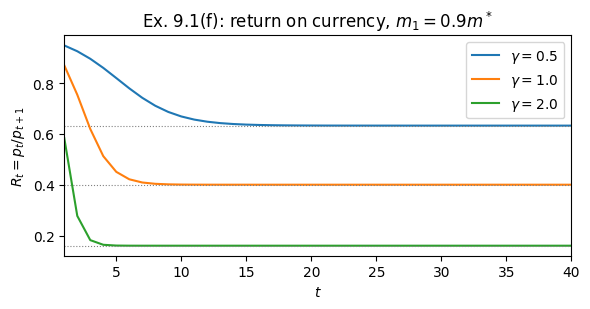

In [2]:
w1, w2 = 1.0, 0.4
for gam in (0.5, 1.0, 2.0):
    for R in (0.5, 0.8, 1.0, 1.3):
        assert abs(s_closed(R, w1, w2, gam) - s_numeric(R, w1, w2, gam)) < 1e-6
    assert np.isclose(s_closed(1.0, w1, w2, gam), (w1 - w2) / 2)       # part (d): s(1) = (w1-w2)/2

up = lambda c, gam: c ** (-gam)
mstar = (w1 - w2) / 2


def next_m(m, gam):
    '''Forward map of 9.1(e): the m' solving m' u'(w2+m') = m u'(w1-m) on [0, m*] (monotone branch).'''
    target = m * up(w1 - m, gam)
    return brentq(lambda x: x * up(w2 + x, gam) - target, 0.0, mstar + 1e-12, xtol=1e-300, rtol=1e-15)


paths = {}
for gam in (0.5, 1.0, 2.0):
    # monotone branch: x (w2+x)^-gam increasing on [0,m*] iff gam<=1 or m* < w2/(gam-1)
    assert gam <= 1 or mstar < w2 / (gam - 1)
    m = [0.9 * mstar]
    for t in range(80):
        m.append(next_m(m[-1], gam))
    m = np.array(m)
    R = m[1:] / m[:-1]
    assert np.all(np.diff(m) < 0)                                      # real balances fall
    assert abs(R[-1] - (w2 / w1) ** gam) < 1e-6                         # part (f)
    assert abs(next_m(mstar, gam) - mstar) < 1e-9                       # m* is a fixed point
    paths[gam] = R
    print(f"gamma={gam}: R_1={R[0]:.4f}, R_80={R[-1]:.6f}, (w2/w1)^gamma={(w2/w1)**gam:.6f}")

fig, ax = plt.subplots(figsize=(6, 3.2))
for gam, R in paths.items():
    ax.plot(np.arange(1, len(R) + 1), R, label=rf"$\gamma={gam}$")
    ax.axhline((w2 / w1) ** gam, ls=":", color="gray", lw=0.8)
ax.set_xlabel("$t$"); ax.set_ylabel(r"$R_t=p_t/p_{t+1}$"); ax.set_xlim(1, 40)
ax.legend(); ax.set_title(r"Ex. 9.1(f): return on currency, $m_1=0.9m^*$")
fig.tight_layout(); fig.savefig(FIG + "ls09_9_1_returns.pdf"); plt.show()

## Exercise 9.2 --- Lenders and borrowers within a generation

Parameters chosen: $w_1=1$, $w_2=0.5$, $N=2$, $M=1$ per initial old. Checks: loan-market root by `brentq`
vs $R=w_2/w_1$; closed-form $p_t=p^*+(p_1-p^*)(w_1/w_2)^{t-1}$ vs the recursion $p_t=4M/w_1+(w_2/w_1)p_{t+1}$;
higher $p_1$ lowers every $R_t$, so lenders lose and borrowers gain (no Pareto ranking).

In [3]:
w1, w2, N, M = 1.0, 0.5, 2, 1.0
excess = lambda R: (N / 2) * s_closed(R, w1, 0.0, 1) + (N / 2) * s_closed(R, 0.0, w2, 1)
Raut = brentq(excess, 1e-6, 10)
assert np.isclose(Raut, w2 / w1)
assert np.isclose(s_numeric(0.7, 0.0, w2, 1), -w2 / (2 * 0.7), atol=1e-6)   # borrower's saving

pstar = 4 * M / (w1 - w2)


def pricepath(p1, T=60):
    return pstar + (p1 - pstar) * (w1 / w2) ** np.arange(T)


for p1 in (pstar, 1.2 * pstar, 2 * pstar):
    p = pricepath(p1)
    assert np.allclose(p[:-1], 4 * M / w1 + (w2 / w1) * p[1:])          # difference equation
    R = p[:-1] / p[1:]
    assert np.allclose((N / 2) * (w1 / 2 - w2 / (2 * R)), N * M / p[:-1])  # money market clears


def utilities(p1, T=30):
    p = pricepath(p1, T + 1); R = p[:-1] / p[1:]
    U1 = np.log(w1 / 2) + np.log(R * w1 / 2)                          # type 1 (lender)
    U2 = np.log(w2 / (2 * R)) + np.log(w2 / 2)                        # type 2 (borrower)
    return U1, U2


U1a, U2a = utilities(pstar); U1b, U2b = utilities(1.5 * pstar)
assert np.all(U1a > U1b) and np.all(U2a < U2b)                        # part (f): not Pareto ranked
print("p* =", pstar, " R_aut =", Raut)

p* = 8.0  R_aut = 0.5000000000000002


## Exercise 9.3 --- A Lucas tree

Numbers from part (c): $w_1=10$, $w_2=5$, $d=10^{-6}$ (per capita dividend), log utility ($\gamma=1$); a
$\gamma=2$ check as well. Checks: stationary $a$ from the quadratic vs `brentq` on $s(R)(R-1)=d$;
paths with $a_1\neq\bar a$ leave the feasible set; with currency valued the tree price would be unbounded.

In [4]:
w1, w2, d = 10.0, 5.0, 1e-6
abar = ((w1 - w2 - 2 * d) + np.sqrt((w1 - w2 - 2 * d) ** 2 + 8 * d * w1)) / 4
Rbar = (abar + d) / abar
for gam in (1.0, 2.0):
    Rg = brentq(lambda R: s_closed(R, w1, w2, gam) * (R - 1) - d, 1 + 1e-12, 2.0, xtol=1e-15, rtol=1e-15)
    ag = s_closed(Rg, w1, w2, gam)
    assert np.isclose(ag * (Rg - 1), d, rtol=1e-6) and Rg > 1
    if gam == 1:
        assert np.isclose(Rg, Rbar, rtol=1e-12, atol=1e-13) and np.isclose(ag, abar)
    print(f"gamma={gam}: R-1={Rg-1:.4e}, a={ag:.7f}, c_y={w1-ag:.7f}")

phi = lambda a: w2 * a / (w1 - 2 * a) - d                              # a_{t+1} under log utility
for a1, fate in ((abar * (1 + 1e-4), "up"), (abar * (1 - 1e-4), "down")):
    a = a1
    for t in range(200000):
        a = phi(a)
        if a <= 0 or a >= w1 / 2:
            break
    assert (a >= w1 / 2) if fate == "up" else (a <= 0)
    print(f"a1 = abar*(1{'+' if fate=='up' else '-'}1e-4): leaves (0, w1/2) at t = {t+2}")

# part (a): valued currency m_t <= w1 makes a_1 >= T d m_1/w1 for every T -> impossible
m1 = 0.1
lower_bound_T = lambda T: T * d * m1 / w1
assert lower_bound_T(10 ** 10) > w1                  # exceeds any feasible tree price a_1 <= w1

gamma=1.0: R-1=4.0000e-07, a=2.5000010, c_y=7.4999990
gamma=2.0: R-1=4.0000e-07, a=2.5000002, c_y=7.4999998
a1 = abar*(1+1e-4): leaves (0, w1/2) at t = 14
a1 = abar*(1-1e-4): leaves (0, w1/2) at t = 35


## Exercise 9.4 --- Population growth, log utility

Parameters chosen: $w_1=1$, $w_2=0.4$, $n=1.1$, $N(0)=1$, $M=1$. Checks: stationary return $R=n$;
money market $N(t)s(n)=M/p_t$ at every date; allocation on the feasibility line $c_y+c_o/n=w_1+w_2/n$.

In [5]:
w1, w2, n, N0, M = 1.0, 0.4, 1.1, 1.0, 1.0
sn = s_closed(n, w1, w2, 1)
t = np.arange(1, 30); Nt = N0 * n ** t
p = M / (Nt * sn)
assert np.allclose(p[:-1] / p[1:], n)
cy, co = w1 - sn, w2 + n * sn
assert np.isclose(cy, (w1 + w2 / n) / 2) and np.isclose(co, (n * w1 + w2) / 2)
assert np.isclose(cy + co / n, w1 + w2 / n)
assert np.isclose(s_numeric(n, w1, w2, 1), sn, atol=1e-6)
print("s(n) =", sn, " c_y, c_o =", cy, co)

s(n) = 0.3181818181818182  c_y, c_o = 0.6818181818181819 0.75


## Exercise 9.5 --- All monetary equilibria with growth

Parameters chosen: $w_1=1$, $w_2=0.5$, $n=0.9>w_2/w_1$, $N(0)=1$. Checks: $p_t=Kn^{-t}+c(w_1/w_2)^t$,
$K=2n/(nw_1-w_2)$, solves $p_{t+1}=(w_1/w_2)p_t-(2/w_2)n^{-t}$; $R_t\to n$ ($c=0$) or $\to w_2/w_1$ ($c>0$);
utilities of every generation and the initial old fall with $c$ (Pareto ranking); no equilibrium when $nw_1\le w_2$.

In [6]:
w1, w2, n = 1.0, 0.5, 0.9
K = 2 * n / (n * w1 - w2)
T = 200
t = np.arange(1, T + 1)


def p_path(c):
    return K * n ** (-t.astype(float)) + c * (w1 / w2) ** t.astype(float)


def gen_utils(c):
    p = p_path(c); R = p[:-1] / p[1:]
    return 2 * np.log(w1 * R + w2) - np.log(R) - 2 * np.log(2), R, p


prev = None
for c in (0.0, 1e-6, 1e-3, 1.0):
    p = p_path(c)
    assert np.allclose(p[1:], (w1 / w2) * p[:-1] - (2 / w2) * n ** (-t[:-1].astype(float)), rtol=1e-9)
    U, R, _ = gen_utils(c)
    mt = 1.0 / (n ** t[:-1] * p[:-1])                              # N(0)/(N(t) p_t)
    assert np.allclose(mt, 0.5 * (w1 - w2 / R))                    # money market
    target = n if c == 0 else w2 / w1
    assert abs(R[-1] - target) < 1e-6
    if prev is not None:
        assert np.all(U <= prev[0] + 1e-12) and 1 / p[0] < 1 / prev[1][0]   # every generation + initial old worse
    prev = (U, p)
# direct check of v(R) against the numerical optimiser
Rchk = 0.75
v_num = np.log(1 - s_numeric(Rchk, w1, w2, 1)) + np.log(w2 + Rchk * s_numeric(Rchk, w1, w2, 1))
assert np.isclose(v_num, 2 * np.log(w1 * Rchk + w2) - np.log(Rchk) - 2 * np.log(2), atol=1e-9)
# n w1 < w2: any c >= 0 gives negative prices eventually
n2 = 0.4
K2 = 2 * n2 / (n2 * w1 - w2)
assert K2 < 0
for c in (0.0, 1.0, 1e3):
    p2 = K2 * n2 ** (-t[:60].astype(float)) + c * (w1 / w2) ** t[:60].astype(float)
    assert p2.min() < 0
print("K =", K)

K = 4.5


## Exercise 9.6 --- Exchange rates (Kareken--Wallace)

Parameters chosen: $N=1$, $\alpha=1$ (world currency demand $N\alpha=1$), $H_1(0)=2$, $H_2(0)=3$,
real deficits $d_1=0.05$, $d_2=0.10$. Part (c): every $e>0$ gives an equilibrium with the same
$R_m=1-(d_1+d_2)/(N\alpha)$ and the same real allocation; only the split of real balances depends on $e$.
Part (d): nominal stocks fixed; the $t=1$ budget pins each price level.

In [7]:
Na, H10, H20, d1, d2 = 1.0, 2.0, 3.0, 0.05, 0.10
Rm = 1 - (d1 + d2) / Na


def kw_path(e, T=200):
    '''9.6(c): money-financed real deficits; returns (h1, h2, p1) paths for exchange rate e.'''
    p1 = (H10 + e * H20) / (Na - d1 - d2)
    H1, H2, h1, h2, P = H10, H20, [], [], []
    for k in range(T):
        H1 += p1 * d1; H2 += (p1 / e) * d2
        h1.append(H1 / p1); h2.append(H2 * e / p1); P.append(p1)
        p1 = p1 / Rm
    return np.array(h1), np.array(h2), np.array(P)


for e in (0.2, 1.0, 5.0):
    h1, h2, P = kw_path(e)
    assert np.allclose(h1 + h2, Na)                           # world money market every date
    assert np.allclose(P[:-1] / P[1:], Rm)                    # same return for every e
    assert h1.min() > 0 and h2.min() > 0                      # both currencies valued
    assert abs(h1[-1] - d1 / (1 - Rm)) < 1e-6                 # split converges to d_i/(1-R_m)
e_stat = H10 * d2 / (H20 * d1)
h1s, h2s, _ = kw_path(e_stat)
assert np.allclose(h1s, d1 / (1 - Rm))                        # the unique constant-split e
print("R_m =", Rm, " e with stationary split =", e_stat)

# part (d): H_i(1) exogenous, S_i = G_i - T_i - B_i(1) real t=1 seigniorage
H11, H21, S1, S2 = 2.2, 3.3, 0.04, 0.06
p1, p2 = (H11 - H10) / S1, (H21 - H20) / S2
Na_d = H11 / p1 + H21 / p2                                    # existence restriction: world demand must equal this
assert np.isclose(H11 / p1 - H10 / p1, S1) and np.isclose(H21 / p2 - H20 / p2, S2)
print("(d): p1 =", p1, " p2 =", p2, " e =", p1 / p2, " required N*alpha =", Na_d)

R_m = 0.85  e with stationary split = 1.3333333333333333
(d): p1 = 5.000000000000004  p2 = 4.999999999999997  e = 1.0000000000000013  required N*alpha = 1.1


## Exercise 9.7 --- Credit controls

Parameter chosen: $y=1$, $N=2$, $H(0)=1$. Checks: loan-market root $1+r=1$ (no controls) and $1/2$ (limit $y/4$);
no monetary equilibrium without controls ($x_{t+1}=x_t/(1-x_t)$ leaves $(0,1)$); $q=8/y$ with controls;
welfare comparisons of part (g); goods-market feasibility.

In [8]:
y, N, H0 = 1.0, 2, 1.0
lend = lambda R: y / 2                                   # lender saving (log, (y,0))
borrow_free = lambda R: y / (2 * R)                      # borrower's desired borrowing
borrow_lim = lambda R: min(y / (2 * R), y / (4 * R))     # repayment R*b <= y/4
R_b = brentq(lambda R: lend(R) - borrow_free(R), 0.1, 10)
R_e = brentq(lambda R: lend(R) - borrow_lim(R), 0.1, 10)
assert np.isclose(R_b, 1.0) and np.isclose(R_e, 0.5)
assert np.isclose(s_numeric(0.8, 0.0, y, 1), -y / (2 * 0.8), atol=1e-6)

for x1 in (1e-3, 0.1, 0.5):                              # part (d)
    x = x1
    for t in range(10 ** 5):
        x = x / (1 - x)
        if not (0 < x < 1):
            break
    assert not (0 < x < 1)

p = 8 * H0 / (N * y); q = p * N / H0                     # part (f)
assert np.isclose((N / 2) * (lend(1.0) - borrow_lim(1.0)), H0 / p) and np.isclose(q, 8 / y)
cL_f, cB_f, c0_f = (y / 2, y / 2), (y / 4, 3 * y / 4), H0 / (N * p)
assert np.isclose((N / 2) * (cL_f[0] + cB_f[0]) + N * c0_f, (N / 2) * y)          # t = 1
assert np.isclose((N / 2) * (cL_f[0] + cB_f[0] + cL_f[1] + cB_f[1]), N * y)       # t >= 2
U = lambda c: np.log(c[0]) + np.log(c[1])
assert np.isclose(U((y / 2, y / 2)), U(cL_f))                                     # lenders: equal
assert U(cB_f) < U((y / 2, y / 2)) and c0_f > 0                                   # borrowers worse, old better
print("q =", q, " old consumption y/8 =", c0_f)

q =

 8.0  old consumption y/8 = 0.125


## Exercise 9.8 --- Inside money and real bills

Parameters chosen: $N_1=3$, $N_2=2$, $y=1$, $Y=1$ (so $1+r=N_2Y/(N_1y)=2/3<1$), $H_0=1$, $L_g=0.1$.
Checks: nonmonetary root; quantity-theory $q=2/(N_1y-N_2Y)$; borrowers lose at $R=1$; with inside money
the loan market clears at the same $\bar p$.

In [9]:
N1, N2, y, Y, H0, Lg = 3, 2, 1.0, 1.0, 1.0, 0.1
agg = lambda R: N1 * y / 2 - N2 * Y / (2 * R)
R_aut = brentq(agg, 1e-3, 10)
assert np.isclose(R_aut, N2 * Y / (N1 * y)) and R_aut < 1
q = 2 / (N1 * y - N2 * Y); pbar = q * H0
assert np.isclose(agg(1.0), H0 / pbar)
Ub = lambda R: np.log(Y / (2 * R)) + np.log(Y / 2)          # type 2 utility, decreasing in R
assert Ub(1.0) < Ub(R_aut)                                   # (c): not Pareto superior
# (d): lenders' saving = currency (H0 + M_I)/p + private loans; borrowers = private loans + Lg
MI = Lg * pbar
private_loans = N2 * Y / 2 - Lg
assert np.isclose(N1 * y / 2, (H0 + MI) / pbar + private_loans)
# N1 > N2 Y/y case with 1+r > 1 : saving at R=1 negative -> no quantity-theory equilibrium (b)
assert (lambda R: 2 * y / 2 - 3 * Y / (2 * R))(1.0) < 0
print("1+r_aut =", R_aut, " q =", q)

1+r_aut = 0.6666666666669707  q = 2.0


## Exercise 9.9 --- Social security and the price level

Parameters chosen: $y=1$, $N=1$, $H=1$. Checks: economy I price $2H/(Ny)$; economy II stationary
$p^*=2H/(N(y-2\tau))$ and the continuum $p_t=p^*+c[(y-\tau)/\tau]^t$; allocation $(y/2,y/2)$ for every $\tau<y/2$.

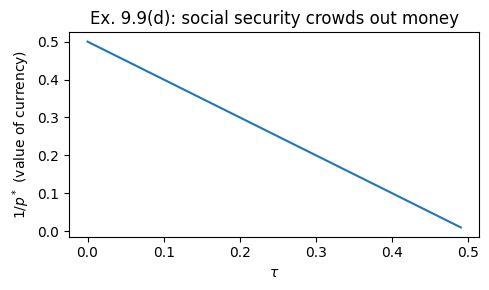

In [10]:
y, N, H = 1.0, 1.0, 1.0
taus = np.linspace(0, 0.49, 50)
for tau in (0.0, 0.1, 0.3, 0.45):
    ps = 2 * H / (N * (y - 2 * tau))
    m = H / (N * ps)
    if tau > 0:
        assert np.isclose(m, s_closed(1.0, y - tau, tau, 1))
        assert np.isclose(s_numeric(1.0, y - tau, tau, 1), m, atol=1e-6)
        rho = (y - tau) / tau
        for c in (0.0, 0.5):
            p = ps + c * rho ** np.arange(1, 20)
            assert np.allclose(p[1:], rho * p[:-1] - 2 * H / (N * tau))
    assert np.isclose(y - tau - m, y / 2) and np.isclose(tau + m, y / 2)
pstar = 2 * H / (N * (y - 2 * taus))
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(taus, N * (y - 2 * taus) / (2 * H))
ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"$1/p^*$ (value of currency)")
ax.set_title("Ex. 9.9(d): social security crowds out money")
fig.tight_layout(); fig.savefig(FIG + "ls09_9_9_socsec.pdf"); plt.show()

## Exercise 9.10 --- Seignorage

Parameters chosen: $N_1=N_2=1$, $\alpha=1$, $\beta=0.25$ (so $N_2\beta/N_1\alpha=0.25$), $H(0)=1$.
Checks: $x_t=1/m_t$ is linear, $x_{t+1}=(A/B)x_t-2/B$; continuum for $1/z>N_2\beta/N_1\alpha$, none otherwise;
$G(z)$ maximised at $z^*=\sqrt{N_1\alpha/N_2\beta}$ (grid vs formula); Laffer figure.

z* = 2.0  zmax = 4.0  Gmax = 0.125


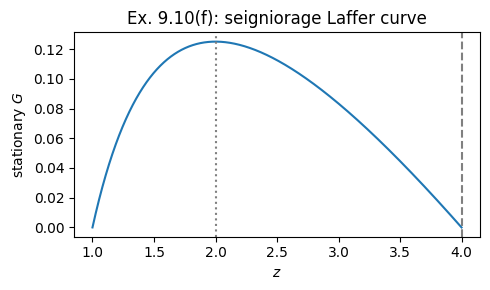

In [11]:
N1, N2, al, be = 1.0, 1.0, 1.0, 0.25
A = N1 * al
zmax = N1 * al / (N2 * be)


def m_path(m1, z, T=400):
    B = N2 * be * z
    m = [m1]
    for _ in range(T):
        den = A - 2 * m[-1]
        if den <= 0 or m[-1] <= 0:
            return np.array(m), False
        m.append(B * m[-1] / den)
    return np.array(m), True


z = 2.0
B = N2 * be * z; mstar = (A - B) / 2
m, ok = m_path(mstar, z); assert ok and np.allclose(m, mstar)
m, ok = m_path(0.5 * mstar, z); assert ok and m[-1] < 1e-12            # continuum, m -> 0
x = 1 / m[:50]; assert np.allclose(x[1:], (A / B) * x[:-1] - 2 / B)     # linear in 1/m
m, ok = m_path(1.01 * mstar, z); assert not ok                          # above m*: explodes
# money market and returns in the stationary equilibrium
R = 1 / z
assert np.isclose(N1 * al / 2 - N2 * be / (2 * R), mstar)
# (e): z above zmax -> every m1 fails
for m1 in (1e-4, 0.01, 0.1, 0.3):
    assert not m_path(m1, 1.2 * zmax, T=5000)[1]
G = lambda z: (1 - 1 / z) * (N1 * al - N2 * be * z) / 2
zg = np.linspace(1, zmax, 200001)
zstar = np.sqrt(zmax)
assert abs(zg[np.argmax(G(zg))] - zstar) < 1e-3
assert np.isclose(G(zstar), 0.5 * (np.sqrt(N1 * al) - np.sqrt(N2 * be)) ** 2)
print("z* =", zstar, " zmax =", zmax, " Gmax =", G(zstar))
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(zg, G(zg)); ax.axvline(zstar, ls=":", color="gray"); ax.axvline(zmax, ls="--", color="gray")
ax.set_xlabel("$z$"); ax.set_ylabel("stationary $G$")
ax.set_title("Ex. 9.10(f): seigniorage Laffer curve")
fig.tight_layout(); fig.savefig(FIG + "ls09_9_10_laffer.pdf"); plt.show()

## Exercise 9.11 --- Unpleasant monetarist arithmetic

Example demand (chosen): the log OLG saving function $g(R)=(w_1-w_2/R)/2$ with $w_1=1$, $w_2=0.25$, so
$\underline R=0.25$, $R_m=0.5$, $h(R_m)=0.125$; $D=0.05$, $R_2=1.05$. Checks: two stationary roots of
$h(R)=D+(R_2-1)B$ for $B<\bar B=(h(R_m)-D)/(R_2-1)$; on the good side $R$ falls with $B$ (inflation rises).

Bbar = 1.4999999999999987  R(good) at B=0: 0.8589454172900137  at B~Bbar: 0.5402588699523334


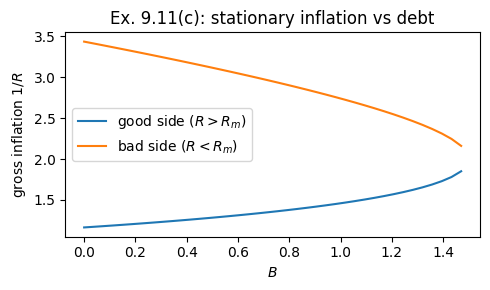

In [12]:
w1, w2, D, R2 = 1.0, 0.25, 0.05, 1.05
g = lambda R: (w1 - w2 / R) / 2
h = lambda R: g(R) * (1 - R)
Rlow, Rm = w2 / w1, np.sqrt(w2 / w1)
assert np.isclose(minimize_scalar(lambda R: -h(R), bounds=(Rlow, 1), method="bounded").x, Rm, atol=1e-5)
Bbar = (h(Rm) - D) / (R2 - 1)
Bs = np.linspace(0, 0.98 * Bbar, 40)
good, bad = [], []
for B in Bs:
    target = D + (R2 - 1) * B
    good.append(brentq(lambda R: h(R) - target, Rm, 1.0))
    bad.append(brentq(lambda R: h(R) - target, Rlow, Rm))
    # quadratic route: w1 R^2 - (w1 + w2 - 2 target) R + w2 = 0
    roots = np.sort(np.roots([w1, -(w1 + w2 - 2 * target), w2]).real)
    assert np.allclose(roots, [bad[-1], good[-1]])
good, bad = np.array(good), np.array(bad)
assert np.all(np.diff(good) < 0) and np.all(np.diff(bad) > 0)
# t = 1 price: p(1) M(0) = g(R) + B - D > 0
assert np.all(g(good) + Bs - D > 0)
print("Bbar =", Bbar, " R(good) at B=0:", good[0], " at B~Bbar:", good[-1])
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(Bs, 1 / good, label="good side ($R>R_m$)"); ax.plot(Bs, 1 / bad, label="bad side ($R<R_m$)")
ax.set_xlabel("$B$"); ax.set_ylabel(r"gross inflation $1/R$"); ax.legend()
ax.set_title("Ex. 9.11(c): stationary inflation vs debt")
fig.tight_layout(); fig.savefig(FIG + "ls09_9_11_debt.pdf"); plt.show()

## Exercise 9.12 --- Grandmont--Hall

Saving function chosen: $f(R)=(w_1-w_2/R)/2$ with $w_1=1$, $w_2=0.5$ ($f(0^+)=-\infty$, $f'>0$, $f(1)=0.25>0$),
$H(0)=1$. Checks: with $p(t)=\bar p$ the recursion $f(1+r(t))=H(t)/\bar p$, $H(t+1)=(1+r(t))H(t)$ gives $r(t)=0$;
any other $p(t)$ breaks the arbitrage condition.

In [13]:
w1, w2, H0 = 1.0, 0.5, 1.0
f = lambda R: (w1 - w2 / R) / 2
pbar = H0 / f(1.0)
# With p(t) = pbar: f(R_t) = H(t)/pbar and H(t+1) = R_t H(t)  =>  f(R_{t+1}) = R_t f(R_t).
nxt = lambda R: brentq(lambda x: f(x) - R * f(R), 1e-9, 1e3, xtol=1e-15, rtol=1e-15)
R1 = brentq(lambda R: f(R) - H0 / pbar, 1e-6, 100, xtol=1e-15, rtol=1e-15)   # H(1) = H(0)
assert np.isclose(R1, 1.0, atol=1e-14) and np.isclose(nxt(1.0), 1.0, atol=1e-14)
# Only the initial condition H(1) = H(0) pins R_1 = 1; the difference equation alone is unstable at R = 1:
growth = 1 + f(1.0) / (w2 / 2)                                 # d R_{t+1}/d R_t at 1 = (f + f')/f'
for R in (1 + 1e-6, 1 - 1e-6):
    path = [R]
    for t in range(400):
        if path[-1] * f(path[-1]) >= w1 / 2:                   # saving would exceed sup f = w1/2
            break
        path.append(nxt(path[-1]))
    assert np.isclose((path[2] - 1) / (path[1] - 1), growth, rtol=1e-3)
    if R > 1:
        assert len(path) < 400                                 # explodes: infeasible in finite time
    else:
        assert abs(path[-1] - w2 / w1) < 1e-6                  # drifts to autarky, but f(R_1) != H(0)/pbar
        assert abs(f(R) - H0 / pbar) > 1e-8
for p in (0.9 * pbar, 1.1 * pbar):
    assert not np.isclose(p / pbar, 1.0)                       # p(t) != pbar violates 1+r = (1+r) p(t)/pbar
print("pbar =", pbar)

pbar = 4.0


## Exercise 9.13 --- Bryant--Keynes--Wallace

Parameters chosen: $w_1=1$, $w_2=0.25$, $N=1$, $g=0.05<h_{\max}=0.125$. Checks: roots of $s(R)(1-R)=g$ have
product $w_2/w_1$; the high-$R$ equilibrium Pareto dominates the low-$R$ one; the golden-rule allocation beats
both; forced saving $F=s(\bar R)$, $1+r_2=\bar R$ replicates; optimal $F=(w_1-w_2+g)/2$ (numerical max).

In [14]:
w1, w2, g = 1.0, 0.25, 0.05
s = lambda R: s_closed(R, w1, w2, 1)
Rm = np.sqrt(w2 / w1)
R_lo = brentq(lambda R: s(R) * (1 - R) - g, w2 / w1, Rm)
R_hi = brentq(lambda R: s(R) * (1 - R) - g, Rm, 1.0)
assert np.isclose(R_lo * R_hi, w2 / w1)                               # (c)
v = lambda R: np.log(w1 - s(R)) + np.log(w2 + R * s(R))
c0 = lambda R: w2 + s(R) - g                                          # initial old
assert v(R_hi) > v(R_lo) and c0(R_hi) > c0(R_lo)
cg = (w1 + w2 - g) / 2
assert 2 * np.log(cg) > v(R_hi) and cg > c0(R_hi)                     # (d): golden rule dominates
# (e) replicate: F = s(R), 1 + r2 = R, budget g = B - B(1+r2)
for R in (R_lo, R_hi):
    F = s(R); assert np.isclose(g, F - F * R)
    assert np.isclose(s_numeric(R, w1, w2, 1), F, atol=1e-6)
# (f)
res = minimize_scalar(lambda B: -(np.log(w1 - B) + np.log(w2 + B - g)), bounds=(g - w2 + 1e-9, w1 - 1e-9),
                      method="bounded", options={"xatol": 1e-12})
Fopt = (w1 - w2 + g) / 2; r2p1 = (w1 - w2 - g) / (w1 - w2 + g)
assert np.isclose(res.x, Fopt, atol=1e-6) and np.isclose(g, Fopt - Fopt * r2p1)
assert s_closed(r2p1, w1, w2, 1) < Fopt                              # constraint B >= F binds
assert 2 * np.log(cg) > np.log(w1) + np.log(w2)                       # better than autarky
print("R_lo, R_hi =", R_lo, R_hi, " F* =", Fopt, " 1+r2 =", r2p1)

R_lo, R_hi = 0.29105458270998635 0.8589454172900137  F* = 0.4  1+r2 = 0.8749999999999999


All asserts passed: every number quoted in `ls_solutions_ch09.pdf` is reproduced above.